# Baseline DenseNet

- DenseNet121, no pretrained weights
- Simple linear classifier head
- No class weighting
- BCEWithLogitsLoss, Adam optimizer

### 1. Import Libraries

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.densenet_baseline import DenseNetBaseline
from src.training.trainer import train_one_epoch, validate_one_epoch

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


### 2. Use Cuda else MPS

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


### 3. Load dataset

- Use DenseNetBaseline model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

model = DenseNetBaseline().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


### 4. Train Model

In [4]:
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

Epoch [1/20] | Train Loss: 0.3203, Train Acc: 0.8777 | Val Loss: 0.2836, Val Acc: 0.8844


Epoch [2/20] | Train Loss: 0.2642, Train Acc: 0.8930 | Val Loss: 0.2795, Val Acc: 0.8859


Epoch [3/20] | Train Loss: 0.2554, Train Acc: 0.8948 | Val Loss: 0.2780, Val Acc: 0.8849


Epoch [4/20] | Train Loss: 0.2467, Train Acc: 0.8960 | Val Loss: 0.2631, Val Acc: 0.8883


Epoch [5/20] | Train Loss: 0.2450, Train Acc: 0.8978 | Val Loss: 0.2665, Val Acc: 0.8883


...

Epoch [16/20] | Train Loss: 0.2093, Train Acc: 0.9064 | Val Loss: 0.2826, Val Acc: 0.8790


Epoch [17/20] | Train Loss: 0.2025, Train Acc: 0.9134 | Val Loss: 0.2560, Val Acc: 0.8888


Epoch [18/20] | Train Loss: 0.2013, Train Acc: 0.9101 | Val Loss: 0.2559, Val Acc: 0.8962


Epoch [19/20] | Train Loss: 0.1981, Train Acc: 0.9170 | Val Loss: 0.2666, Val Acc: 0.8982


Epoch [20/20] | Train Loss: 0.1893, Train Acc: 0.9189 | Val Loss: 0.2556, Val Acc: 0.8953


### 5. Plot Loss and Accuracy Curves

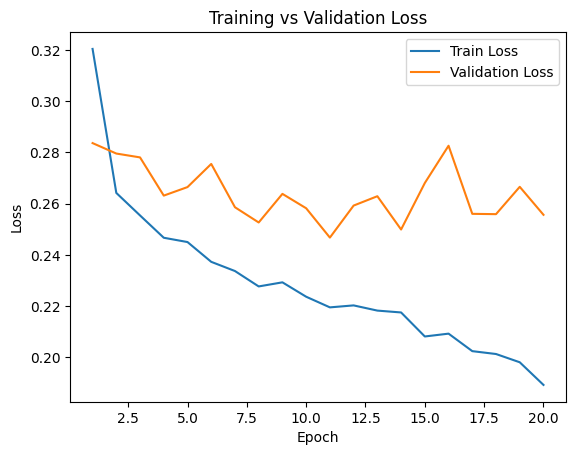

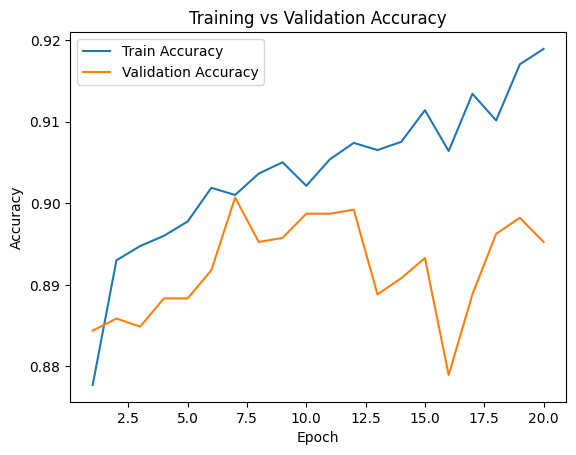

In [5]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model

[[TN, FP],<br/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → "When the model says YES, how often is it correct?"<br/>
Recall → "Out of all actual YES, how many did we catch?"

In [6]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= 0.5)                       # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print(classification_report(all_labels, all_preds, digits=4))

Confusion Matrix:
[[1287   53]
 [ 102   69]]
              precision    recall  f1-score   support

           0     0.9266    0.9604    0.9432      1340
           1     0.5656    0.4035    0.4710       171

    accuracy                         0.8974      1511
   macro avg     0.7461    0.6820    0.7071      1511
weighted avg     0.8857    0.8974    0.8898      1511



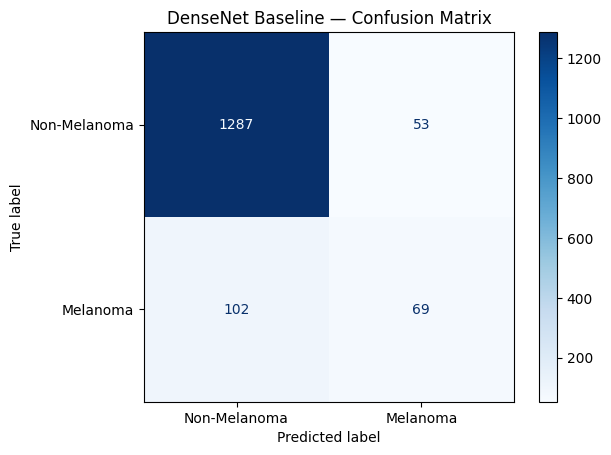

In [7]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("DenseNet Baseline — Confusion Matrix")
plt.show()